<a href="https://colab.research.google.com/github/sanskriti-0312/Machine_Learning_Assignments/blob/main/ML_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 8)
Target Shape: (20640,)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc   

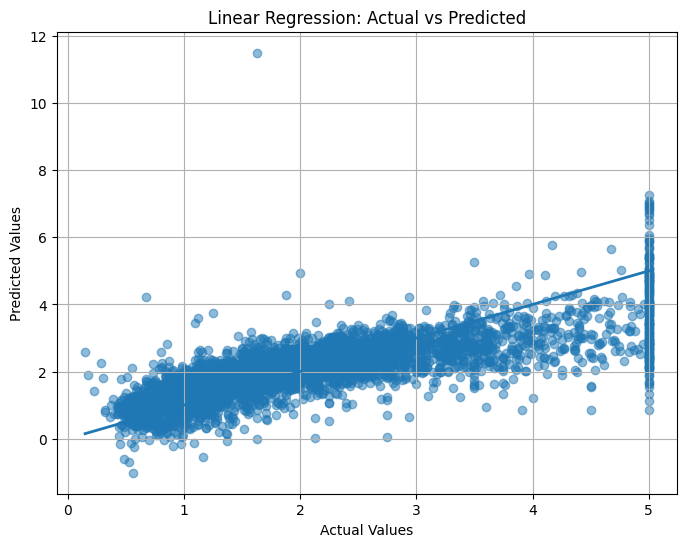

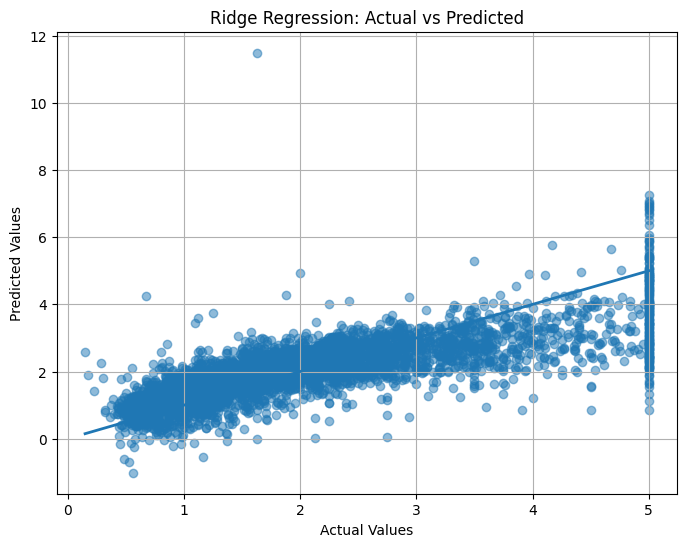

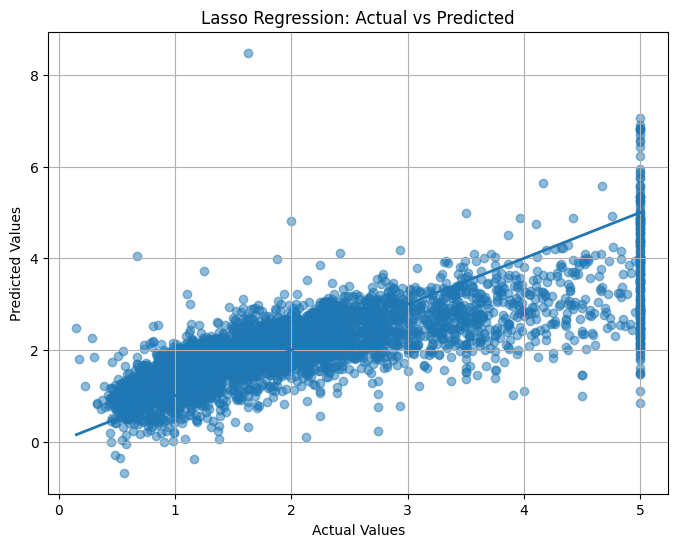

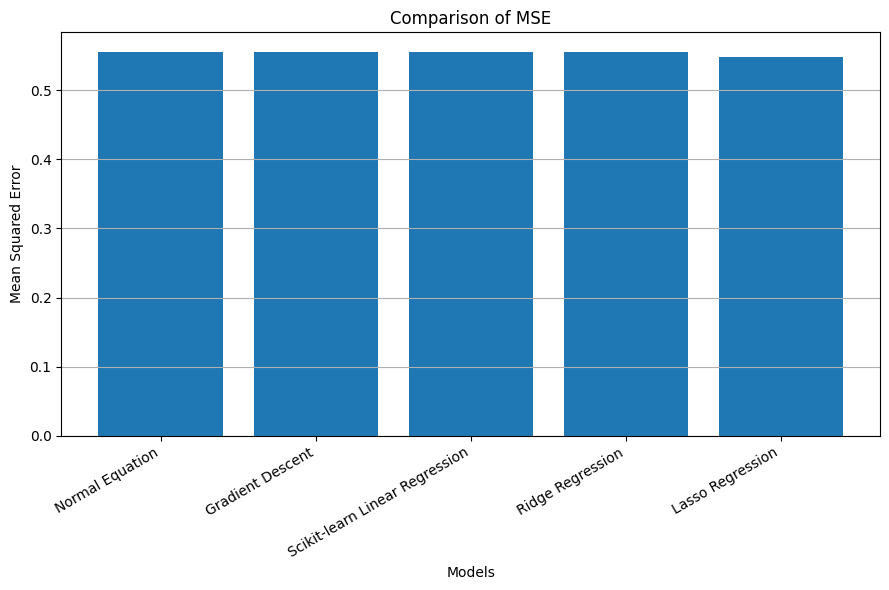

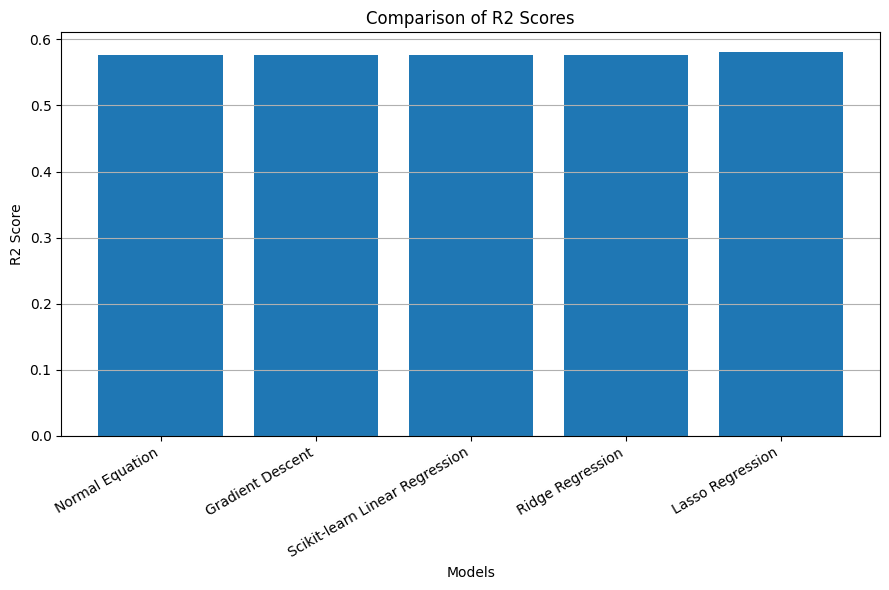

In [1]:
# ============================================================
# LAB EXPERIMENT 1: LINEAR REGRESSION AND REGULARIZATION
# ============================================================

# ------------------------------------------------------------
# 1. Import Required Libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# ------------------------------------------------------------
# 2. Load California Housing Dataset
# ------------------------------------------------------------

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Names:")
print(housing.feature_names)


# ------------------------------------------------------------
# 3. Convert Dataset into DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(X, columns=housing.feature_names)
df["Target"] = y

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------
# 4. Split Dataset into Training and Testing Data
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 5. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# PART A: LINEAR REGRESSION USING NORMAL EQUATION
# ============================================================

print("\n==============================================")
print("LINEAR REGRESSION USING NORMAL EQUATION")
print("==============================================")


# Add bias/intercept column
X_train_bias = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_bias = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]


# Normal Equation:
# theta = (X^T X)^(-1) X^T y
#
# np.linalg.pinv() is used instead of inverse
# because it is more numerically stable.

theta = np.linalg.pinv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train


# Predictions
y_pred_normal = X_test_bias @ theta


# Evaluation
mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

print("MSE:", mse_normal)
print("R2 Score:", r2_normal)


# ============================================================
# PART B: LINEAR REGRESSION USING GRADIENT DESCENT
# ============================================================

print("\n==============================================")
print("LINEAR REGRESSION USING GRADIENT DESCENT")
print("==============================================")


# Number of samples and features
m, n = X_train_scaled.shape

# Add bias column
X_gd = np.c_[
    np.ones(m),
    X_train_scaled
]

X_test_gd = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]


# Initialize parameters
theta_gd = np.zeros(n + 1)

# Learning rate
learning_rate = 0.01

# Number of iterations
iterations = 2000


# Gradient Descent
for i in range(iterations):

    # Calculate predictions
    y_pred = X_gd @ theta_gd

    # Calculate error
    error = y_pred - y_train

    # Calculate gradient
    gradient = (2 / m) * (X_gd.T @ error)

    # Update parameters
    theta_gd = theta_gd - learning_rate * gradient


# Predictions on test data
y_pred_gd = X_test_gd @ theta_gd


# Evaluation
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("MSE:", mse_gd)
print("R2 Score:", r2_gd)


# ============================================================
# PART C: LINEAR REGRESSION USING SCIKIT-LEARN
# ============================================================

print("\n==============================================")
print("SCIKIT-LEARN LINEAR REGRESSION")
print("==============================================")


linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)


# Evaluation
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("MSE:", mse_linear)
print("R2 Score:", r2_linear)


# ============================================================
# PART D: RIDGE REGRESSION
# ============================================================

print("\n==============================================")
print("RIDGE REGRESSION")
print("==============================================")


ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)


# Evaluation
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)


# ============================================================
# PART E: LASSO REGRESSION
# ============================================================

print("\n==============================================")
print("LASSO REGRESSION")
print("==============================================")


lasso_model = Lasso(alpha=0.01, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)


# Evaluation
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)


# ============================================================
# PART F: COMPARE ALL MODELS
# ============================================================

print("\n==============================================")
print("MODEL COMPARISON")
print("==============================================")


results = pd.DataFrame({
    "Model": [
        "Normal Equation",
        "Gradient Descent",
        "Scikit-learn Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MSE": [
        mse_normal,
        mse_gd,
        mse_linear,
        mse_ridge,
        mse_lasso
    ],

    "R2 Score": [
        r2_normal,
        r2_gd,
        r2_linear,
        r2_ridge,
        r2_lasso
    ]
})


print(results)


# ============================================================
# PART G: DISPLAY MODEL COEFFICIENTS
# ============================================================

print("\n==============================================")
print("MODEL COEFFICIENTS")
print("==============================================")


coefficients = pd.DataFrame({
    "Feature": housing.feature_names,

    "Linear Regression": linear_model.coef_,

    "Ridge": ridge_model.coef_,

    "Lasso": lasso_model.coef_
})

print(coefficients)


# ============================================================
# PART H: ACTUAL VS PREDICTED - LINEAR REGRESSION
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.grid(True)
plt.show()


# ============================================================
# PART I: ACTUAL VS PREDICTED - RIDGE
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")

plt.grid(True)
plt.show()


# ============================================================
# PART J: ACTUAL VS PREDICTED - LASSO
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_lasso,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")

plt.grid(True)
plt.show()


# ============================================================
# PART K: COMPARISON OF MSE
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["MSE"]
)

plt.xlabel("Models")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()


# ============================================================
# PART L: COMPARISON OF R2 SCORE
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Comparison of R2 Scores")

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.tight_layout()
plt.show()